In [2]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.6 MB/s  0:00:00


In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
print(" Libraries loaded successfully.")

 Libraries loaded successfully.


In [4]:
class CovtypeDataLoader:
    """Automated loader fetching and mapping raw dataset fields."""
    def __init__(self):
        self.feature_names = [
            'Elevation', 'Aspect', 'Slope',
            'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
            'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
            'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'
        ] + [f'Wilderness_Area_{i}' for i in range(4)] + [f'Soil_Type_{i}' for i in range(40)]
        
        self.target_name = 'Cover_Type'

    def load_data(self):
        print("[*] Fetching Forest Covertype Dataset via Scikit-Learn...")
        raw_data = fetch_covtype(as_frame=True)
        df = raw_data.frame
        df.columns = self.feature_names + [self.target_name]
        df[self.target_name] = df[self.target_name] - 1
        
        print(f"[+] Dataset Loaded: {df.shape[0]:,} rows | {df.shape[1]} columns")
        return df

loader = CovtypeDataLoader()
data = loader.load_data()
data.head(3)

[*] Fetching Forest Covertype Dataset via Scikit-Learn...
[+] Dataset Loaded: 581,012 rows | 55 columns


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [5]:
class ForestFeatureEngineer(BaseEstimator, TransformerMixin):
    """Engineers spatial distance metrics, topographical shade proxies, and soil composites."""
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out['Euc_Distance_To_Hydrology'] = np.sqrt(
            X_out['Horizontal_Distance_To_Hydrology']**2 + 
            X_out['Vertical_Distance_To_Hydrology']**2
        )
        X_out['Elevation_Hydrology_Diff'] = X_out['Elevation'] - X_out['Vertical_Distance_To_Hydrology']
        X_out['Mean_Amenities_Distance'] = (
            X_out['Horizontal_Distance_To_Hydrology'] +
            X_out['Horizontal_Distance_To_Roadways'] +
            X_out['Horizontal_Distance_To_Fire_Points']
        ) / 3.0
        X_out['Hillshade_Morning_Evening_Diff'] = X_out['Hillshade_9am'] - X_out['Hillshade_3pm']
        X_out['Hillshade_Noon_Evening_Diff'] = X_out['Hillshade_Noon'] - X_out['Hillshade_3pm']
        wilderness_cols = [c for c in X_out.columns if c.startswith('Wilderness_Area_')]
        soil_cols = [c for c in X_out.columns if c.startswith('Soil_Type_')]
        
        X_out['Wilderness_Index'] = np.argmax(X_out[wilderness_cols].values, axis=1)
        X_out['Soil_Index'] = np.argmax(X_out[soil_cols].values, axis=1)
        
        return X_out

engineer = ForestFeatureEngineer()
engineered_data = engineer.transform(data)
print(f"[+] Feature Engineering Completed. Total Features: {engineered_data.shape[1] - 1}")

[+] Feature Engineering Completed. Total Features: 61


In [6]:
X = engineered_data.drop(columns=['Cover_Type'])
y = engineered_data['Cover_Type']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(skf.split(X, y))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
continuous_cols = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points', 'Euc_Distance_To_Hydrology',
    'Elevation_Hydrology_Diff', 'Mean_Amenities_Distance'
]

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

print(f"[+] Training Split: {X_train.shape[0]:,} samples | Validation Split: {X_val.shape[0]:,} samples")

[+] Training Split: 464,809 samples | Validation Split: 116,203 samples


In [7]:
lgb_params = {
    'objective': 'multiclass',
    'num_class': 7,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 300,
    'learning_rate': 0.08,
    'num_leaves': 63,
    'max_depth': 12,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

print("[*] Training Gradient Boosted Decision Trees Model...")
model = lgb.LGBMClassifier(**lgb_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose= False)]
)

print("[+] Model Training Complete.")

[*] Training Gradient Boosted Decision Trees Model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3365
[LightGBM] [Info] Number of data points in the train set: 464809, number of used features: 60
[LightGBM] [Info] Start training from score -1.008939
[LightGBM] [Info] Start training from score -0.718259
[LightGBM] [Info] Start training from score -2.788115
[LightGBM] [Info] Start training from score -5.354534
[LightGBM] [Info] Start training from score -4.114268
[LightGBM] [Info] Start training from score -3.510169
[LightGBM] [Info] Start training from score -3.343858
[+] Model Training Complete.


In [8]:
y_pred = model.predict(X_val)

weighted_f1 = f1_score(y_val, y_pred, average='weighted')
macro_f1 = f1_score(y_val, y_pred, average='macro')

print(f"=== PIPELINE METRICS ===")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro F1-Score:    {macro_f1:.4f}\n")

target_classes = [f"Cover_Type_{i+1}" for i in range(7)]
print(classification_report(y_val, y_pred, target_names=target_classes))

=== PIPELINE METRICS ===
Weighted F1-Score: 0.9402
Macro F1-Score:    0.9295

              precision    recall  f1-score   support

Cover_Type_1       0.94      0.92      0.93     42368
Cover_Type_2       0.94      0.96      0.95     56660
Cover_Type_3       0.96      0.97      0.96      7151
Cover_Type_4       0.92      0.84      0.88       550
Cover_Type_5       0.91      0.85      0.88      1899
Cover_Type_6       0.94      0.94      0.94      3473
Cover_Type_7       0.98      0.96      0.97      4102

    accuracy                           0.94    116203
   macro avg       0.94      0.92      0.93    116203
weighted avg       0.94      0.94      0.94    116203



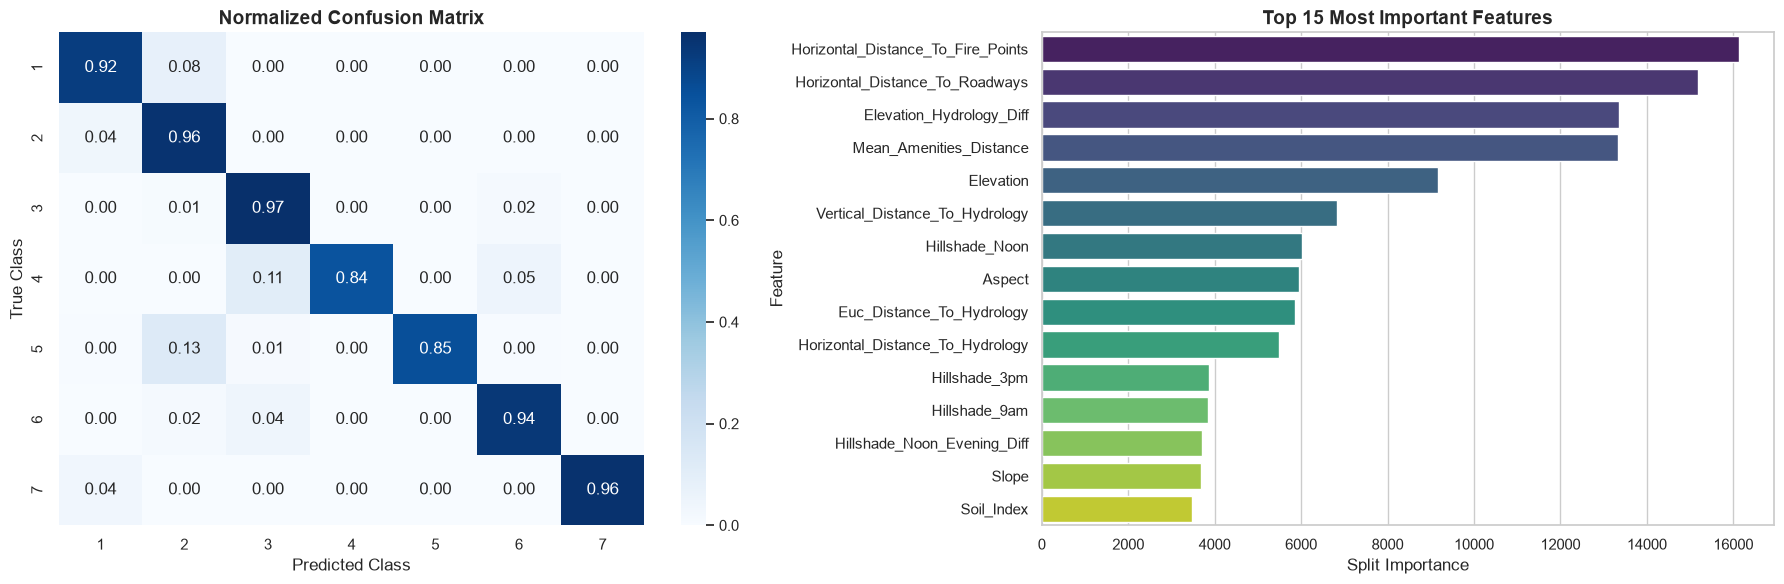

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Confusion Matrix Plot
cm = confusion_matrix(y_val, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=range(1, 8), yticklabels=range(1, 8))
axes[0].set_title("Normalized Confusion Matrix", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

# 2. Feature Importances Plot (Top 15 Features)
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis', ax=axes[1])
axes[1].set_title("Top 15 Most Important Features", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Split Importance")

plt.tight_layout()
plt.show()